<a href="https://colab.research.google.com/github/avram4uk/coursework/blob/main/1glava_kursovoy4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Найдено числовых признаков: 7
Список числовых признаков: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


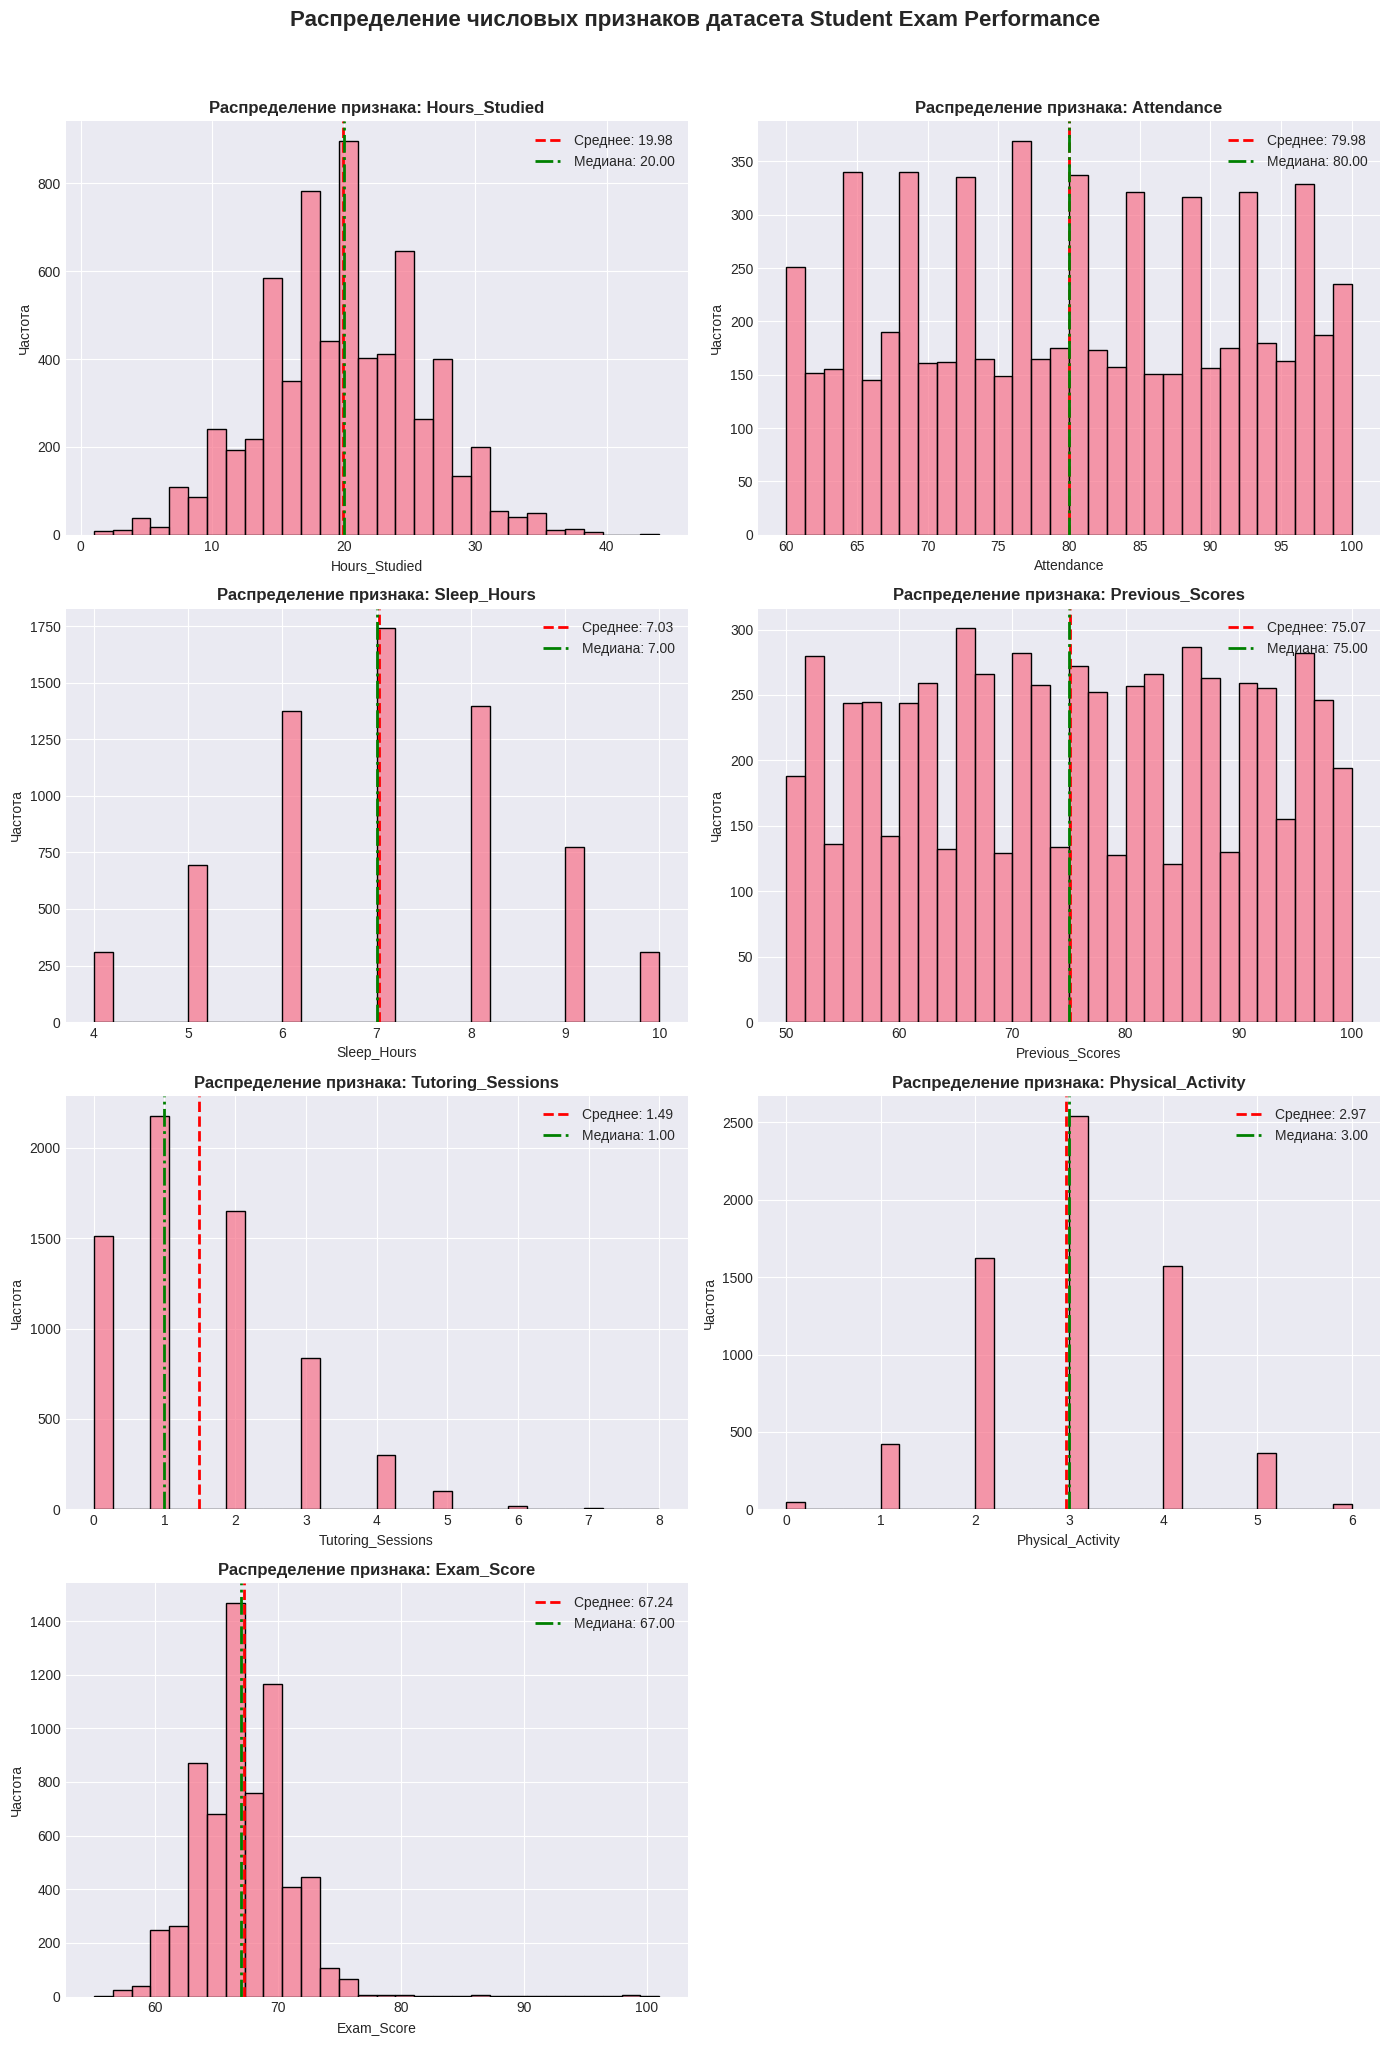

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
df = pd.read_csv('/content/StudentPerformanceFactors.csv')

# Определение числовых признаков
# Автоматически определяем столбцы с числовыми типами данных
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Найдено числовых признаков: {len(numeric_columns)}")
print(f"Список числовых признаков: {numeric_columns}")

# Определяем количество графиков и создаем сетку
n_features = len(numeric_columns)
n_cols = 2  # Количество столбцов в сетке
n_rows = (n_features + n_cols - 1) // n_cols

# Создаем фигуру с субплотами
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()  # Преобразуем в одномерный массив для удобства итерации

# Строим гистограммы с кривой плотности для каждого числового признака
for i, col in enumerate(numeric_columns):
    ax = axes[i]

    # Гистограмма с ядерной оценкой плотности (KDE)
    sns.histplot(data=df, x=col, kde=False, ax=ax, bins=30, alpha=0.7)

    # Добавляем вертикальную линию среднего значения
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Медиана: {median_val:.2f}')

    # Настройка подписей
    ax.set_title(f'Распределение признака: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Частота', fontsize=10)
    ax.legend(loc='upper right')

    # Добавляем информацию о пропусках
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        ax.text(0.95, 0.95, f'Пропуски: {missing_count}',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Удаляем пустые субплоты, если их количество не совпадает с числом признаков
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Распределение числовых признаков датасета Student Exam Performance',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


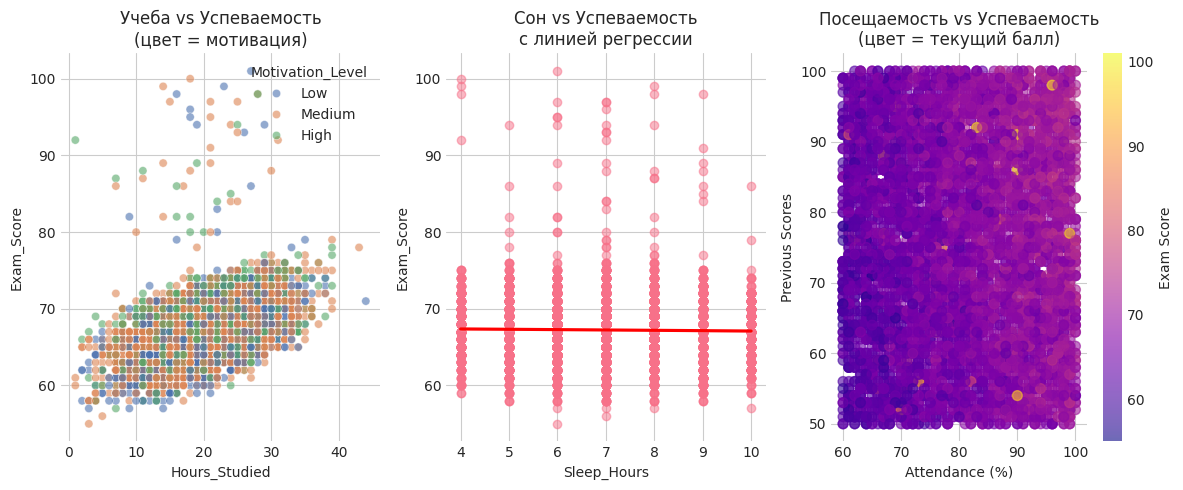

In [ ]:
# Визуализация признаков средствами библиотеки Seaborn
# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Пара 1: Hours_Studied vs Exam_Score (с цветом по Motivation_Level)
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score',
                hue='Motivation_Level', alpha=0.6, palette='deep')
plt.title('Учеба vs Успеваемость\n(цвет = мотивация)')

# Пара 2: Sleep_Hours vs Exam_Score (с регрессией)
plt.subplot(1, 3, 2)
sns.regplot(data=df, x='Sleep_Hours', y='Exam_Score',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Сон vs Успеваемость\nс линией регрессии')

# Пара 3: Attendance vs Previous_Scores (с размером по Exam_Score)
plt.subplot(1, 3, 3)
scatter = plt.scatter(df['Attendance'], df['Previous_Scores'],
                     c=df['Exam_Score'], cmap='plasma',
                     alpha=0.6, s=50)
plt.colorbar(scatter, label='Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Previous Scores')
plt.title('Посещаемость vs Успеваемость\n(цвет = текущий балл)')

plt.tight_layout()
plt.show()

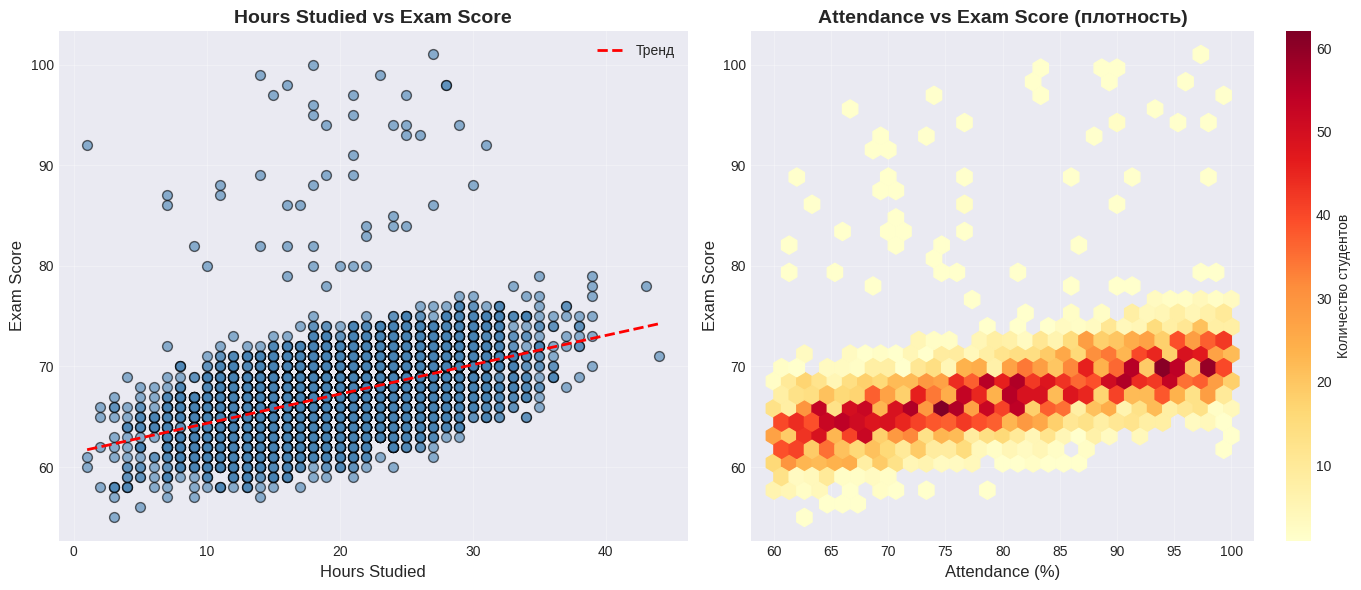

In [ ]:
df_clean = df.dropna()

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Scatter plot (Hours_Studied vs Exam_Score)
axes[0].scatter(df_clean['Hours_Studied'], df_clean['Exam_Score'],
               alpha=0.6, c='steelblue', edgecolors='black', s=50)
axes[0].set_xlabel('Hours Studied', fontsize=12)
axes[0].set_ylabel('Exam Score', fontsize=12)
axes[0].set_title('Hours Studied vs Exam Score', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Добавляем линию тренда
z = np.polyfit(df_clean['Hours_Studied'], df_clean['Exam_Score'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_clean['Hours_Studied'].min(), df_clean['Hours_Studied'].max(), 100)
axes[0].plot(x_trend, p(x_trend), 'r--', linewidth=2, label='Тренд')
axes[0].legend()

# График 2: Hexbin plot (Attendance vs Exam_Score)
hb = axes[1].hexbin(df_clean['Attendance'], df_clean['Exam_Score'],
                    gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Attendance (%)', fontsize=12)
axes[1].set_ylabel('Exam Score', fontsize=12)
axes[1].set_title('Attendance vs Exam Score (плотность)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(hb, ax=axes[1], label='Количество студентов')

plt.tight_layout()
plt.show()

ПОСТРОЕНИЕ ТЕПЛОВЫХ КАРТ ДЛЯ ДАТАСЕТА
Размер датасета: (6607, 20)



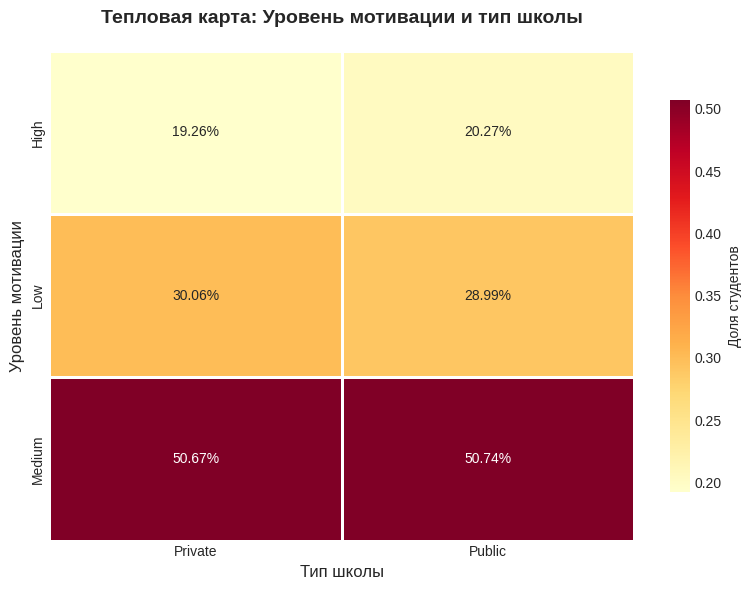

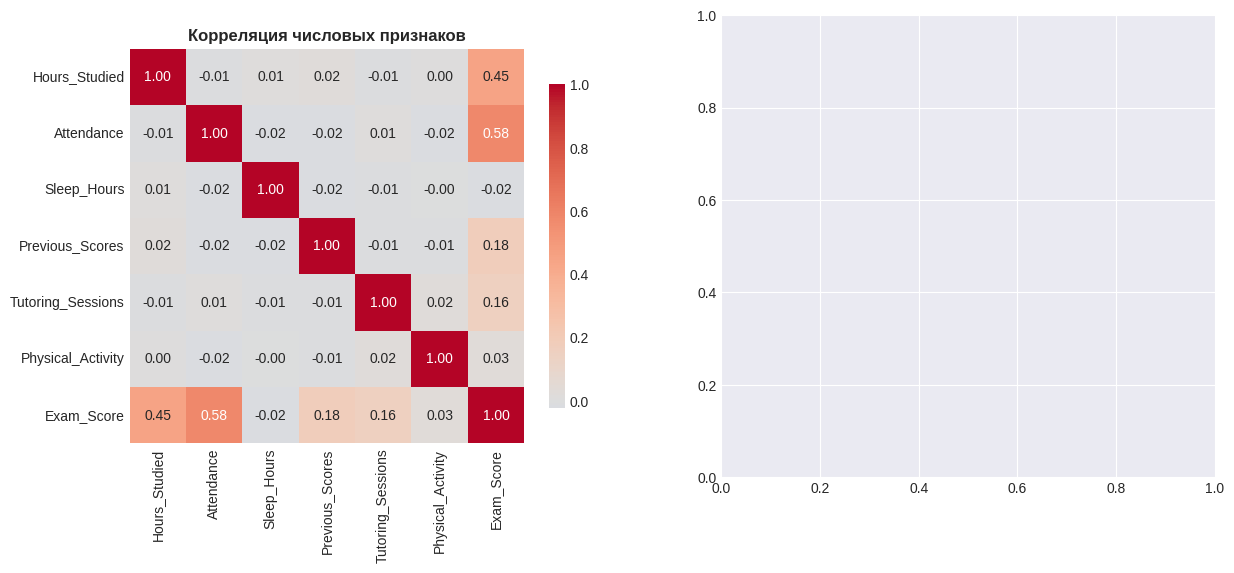

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
# df = pd.read_csv('StudentPerformanceFactors.csv')

print("=" * 60)
print("ПОСТРОЕНИЕ ТЕПЛОВЫХ КАРТ ДЛЯ ДАТАСЕТА")
print("=" * 60)
print(f"Размер датасета: {df.shape}")
print()




# ============================================================================
# Кросс-таблица между категориальными признаками
# ============================================================================


# Выбираем два категориальных признака для анализа
if 'Motivation_Level' in df.columns and 'School_Type' in df.columns:
    # Создаем кросс-таблицу
    cross_tab = pd.crosstab(df['Motivation_Level'], df['School_Type'], normalize='columns')

    fig3, ax3 = plt.subplots(figsize=(8, 6))

    heatmap3 = sns.heatmap(cross_tab,
                           annot=True,           # Показываем значения
                           fmt='.2%',           # Формат процентов
                           cmap='YlOrRd',       # Желто-оранжево-красная схема
                           cbar_kws={"label": "Доля студентов", "shrink": 0.8},
                           linewidths=1,
                           ax=ax3)

    ax3.set_title('Тепловая карта: Уровень мотивации и тип школы',
                  fontsize=14, fontweight='bold', pad=20)
    ax3.set_xlabel('Тип школы', fontsize=12)
    ax3.set_ylabel('Уровень мотивации', fontsize=12)

    plt.tight_layout()
    plt.show()

# ============================================================================
# УПРОЩЕННАЯ ВЕРСИЯ (для быстрого использования)
# ============================================================================

# Простая версия кода для тепловой карты
fig, (ax1_simple, ax2_simple) = plt.subplots(1, 2, figsize=(14, 6))

# Тепловая карта 1: Корреляции числовых признаков
numeric_data = df.select_dtypes(include=[np.number])
if len(numeric_data.columns) > 0:
    corr_simple = numeric_data.corr()
    sns.heatmap(corr_simple,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True,
                cbar_kws={"shrink": 0.7},
                ax=ax1_simple)
    ax1_simple.set_title('Корреляция числовых признаков', fontweight='bold')


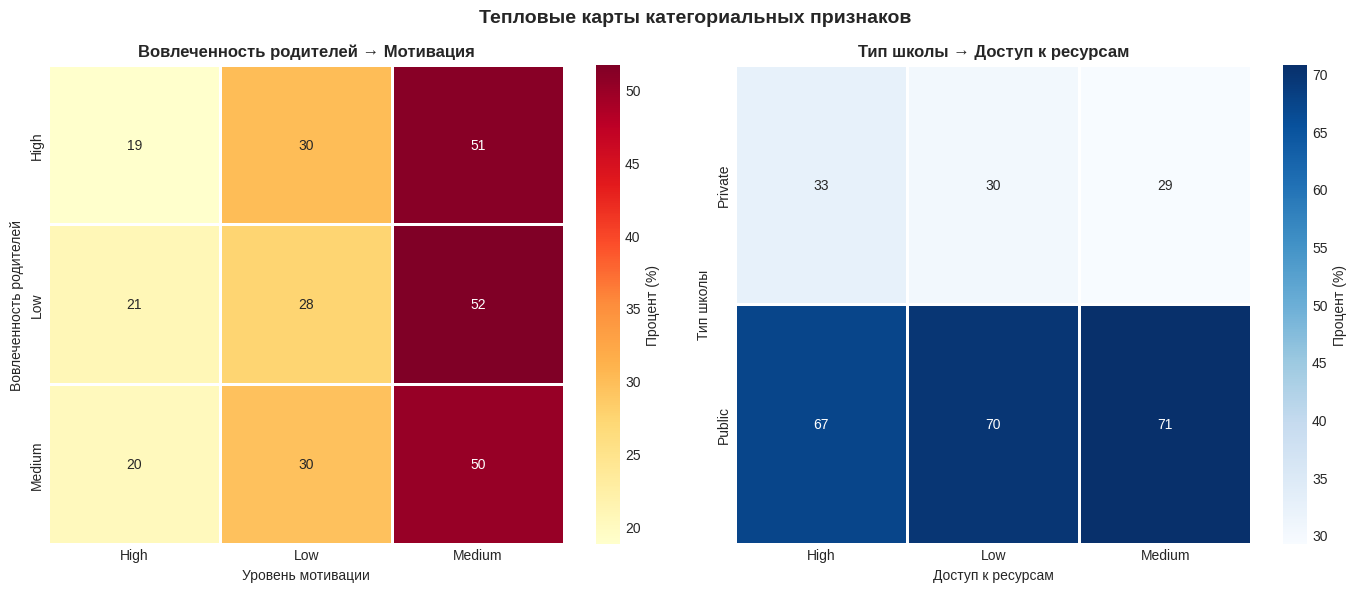


Тепловая карта 1 (Вовлеченность родителей vs Мотивация):
Motivation_Level      High   Low  Medium
Parental_Involvement                    
High                  18.8  30.1    51.1
Low                   20.8  27.5    51.7
Medium                20.3  29.6    50.1

Тепловая карта 2 (Тип школы vs Доступ к ресурсам):
Access_to_Resources  High   Low  Medium
School_Type                            
Private              32.5  30.2    29.2
Public               67.5  69.8    70.8


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
# df = pd.read_csv('StudentPerformanceFactors.csv')

# Создаем фигуру
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ТЕПЛОВАЯ КАРТА 1: Вовлеченность родителей vs Мотивация (в процентах)
cross_tab1 = pd.crosstab(df['Parental_Involvement'],
                         df['Motivation_Level'],
                         normalize='index') * 100

sns.heatmap(cross_tab1,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Процент (%)'},
            linewidths=2,
            ax=ax1)
ax1.set_title('Вовлеченность родителей → Мотивация', fontweight='bold')
ax1.set_xlabel('Уровень мотивации')
ax1.set_ylabel('Вовлеченность родителей')

# ТЕПЛОВАЯ КАРТА 2: Тип школы vs Доступ к ресурсам (в процентах)
cross_tab2 = pd.crosstab(df['School_Type'],
                         df['Access_to_Resources'],
                         normalize='columns') * 100

sns.heatmap(cross_tab2,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            cbar_kws={'label': 'Процент (%)'},
            linewidths=2,
            ax=ax2)
ax2.set_title('Тип школы → Доступ к ресурсам', fontweight='bold')
ax2.set_xlabel('Доступ к ресурсам')
ax2.set_ylabel('Тип школы')

plt.suptitle('Тепловые карты категориальных признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Вывод статистики
print("\nТепловая карта 1 (Вовлеченность родителей vs Мотивация):")
print(cross_tab1.round(1))
print("\nТепловая карта 2 (Тип школы vs Доступ к ресурсам):")
print(cross_tab2.round(1))

In [ ]:
import pandas as pd
# df = pd.read_csv('StudentPerformanceFactors.csv')
print(f"Дубликатов: {df.duplicated().sum()}")
df.drop_duplicates().to_csv('student_performance_clean.csv', index=False)
print("Готово!")

Дубликатов: 0
Готово!


ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR

Hours_Studied:
  Границы: [4.00, 36.00]
  Выбросов: 43 (0.65%)
  Значения выбросов: [43  1 38  3  3]

Attendance:
  Границы: [40.00, 120.00]
  Выбросов: 0 (0.00%)

Sleep_Hours:
  Границы: [3.00, 11.00]
  Выбросов: 0 (0.00%)

Previous_Scores:
  Границы: [25.50, 125.50]
  Выбросов: 0 (0.00%)

Tutoring_Sessions:
  Границы: [-0.50, 3.50]
  Выбросов: 430 (6.51%)
  Значения выбросов: [4 4 5 4 4]

Physical_Activity:
  Границы: [-1.00, 7.00]
  Выбросов: 0 (0.00%)

Exam_Score:
  Границы: [59.00, 75.00]
  Выбросов: 104 (1.57%)
  Значения выбросов: [100  76  79  78  89]


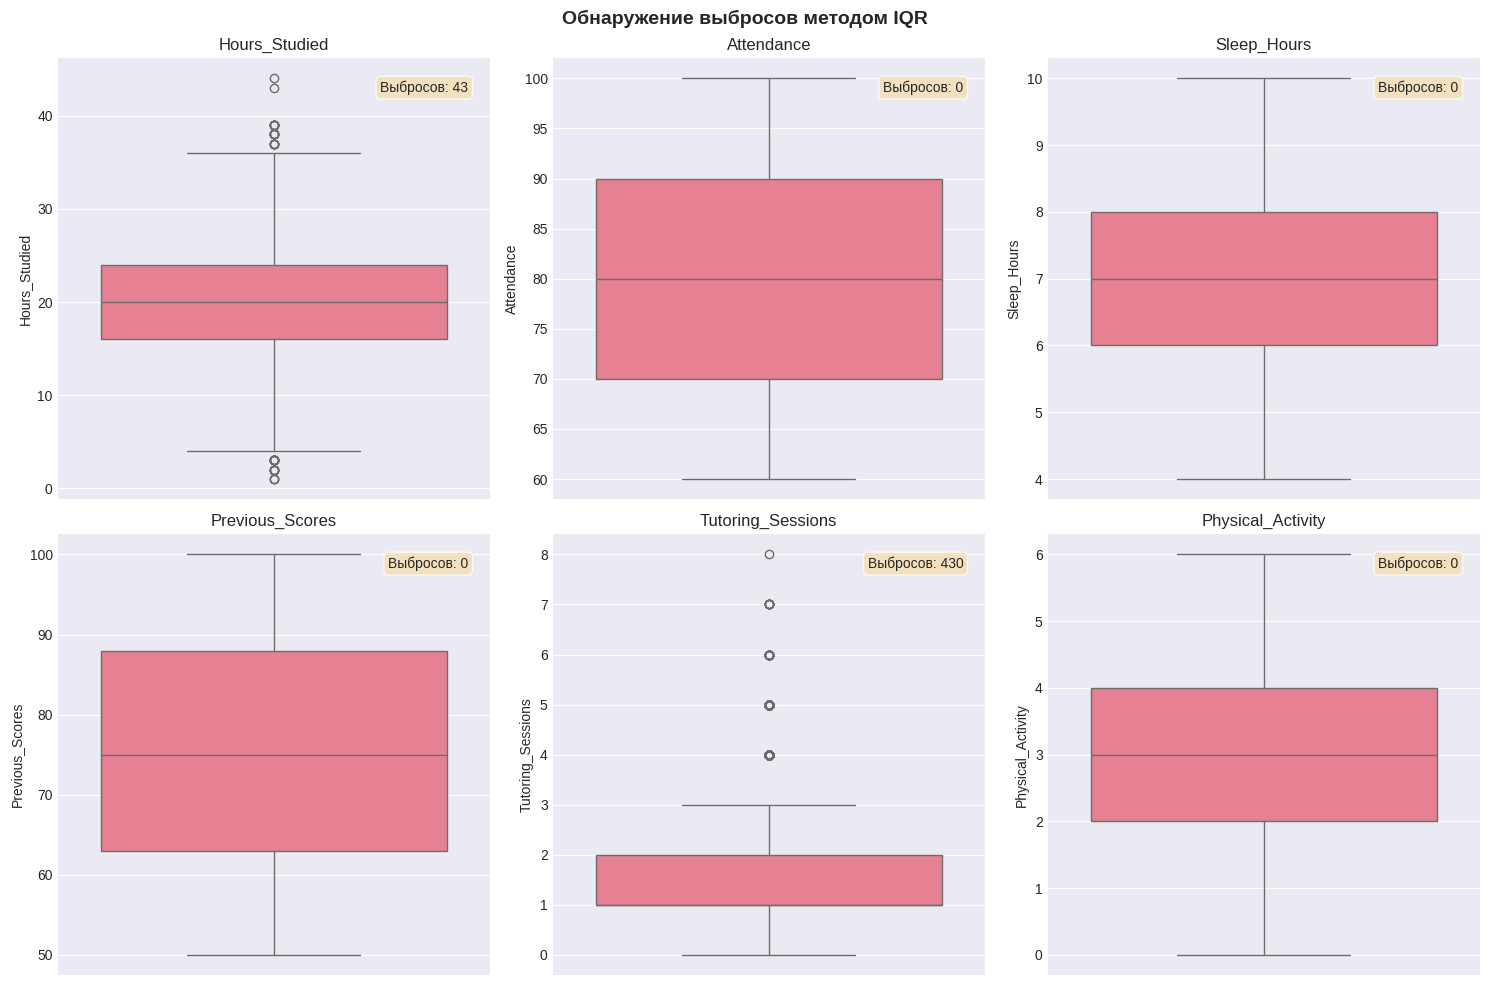

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
# df = pd.read_csv('StudentPerformanceFactors.csv')

# Выбираем числовые признаки
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("=" * 60)
print("ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR")
print("=" * 60)

# Функция для обнаружения выбросов
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Анализ каждого признака
for col in numeric_cols:
    outliers, lower, upper = find_outliers_iqr(df, col)
    print(f"\n{col}:")
    print(f"  Границы: [{lower:.2f}, {upper:.2f}]")
    print(f"  Выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"  Значения выбросов: {outliers[col].values[:5]}")

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        sns.boxplot(y=df[col], ax=axes[idx])
        axes[idx].set_title(col)

        # Добавляем информацию о выбросах
        outliers, _, _ = find_outliers_iqr(df, col)
        axes[idx].text(0.95, 0.95, f'Выбросов: {len(outliers)}',
                      transform=axes[idx].transAxes,
                      verticalalignment='top',
                      horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Обнаружение выбросов методом IQR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("ТРИ ВАРИАНТА ФИЛЬТРАЦИИ ДАННЫХ")
print("=" * 60)

# ФИЛЬТР 1: По одному числовому признаку
print("\n1.  ФИЛЬТР ПО ОДНОМУ ЧИСЛОВОМУ ПРИЗНАКУ")
print("   Условие: Exam_Score >= 85 (отличники)")
filter1 = df[df['Exam_Score'] >= 85]
print(f"   Результат: {len(filter1)} студентов ({len(filter1)/len(df)*100:.2f}%)")
print(f"   Средний балл: {filter1['Exam_Score'].mean():.2f}")

# ФИЛЬТР 2: По одному категориальному признаку
print("\n2.  ФИЛЬТР ПО ОДНОМУ КАТЕГОРИАЛЬНОМУ ПРИЗНАКУ")
print("   Условие: Motivation_Level == 'High' (высокая мотивация)")
filter2 = df[df['Motivation_Level'] == 'High']
print(f"   Результат: {len(filter2)} студентов ({len(filter2)/len(df)*100:.2f}%)")
print(f"   Средний балл: {filter2['Exam_Score'].mean():.2f}")

# ФИЛЬТР 3: По нескольким признакам
print("\n3.  КОМБИНИРОВАННЫЙ ФИЛЬТР ПО НЕСКОЛЬКИМ ПРИЗНАКАМ")
print("   Условия: Exam_Score >= 80, Attendance >= 90, Hours_Studied >= 12")
filter3 = df[(df['Exam_Score'] >= 80) & (df['Attendance'] >= 90) & (df['Hours_Studied'] >= 12)]
print(f"   Результат: {len(filter3)} студентов ({len(filter3)/len(df)*100:.2f}%)")
print(f"   Средний балл: {filter3['Exam_Score'].mean():.2f}")
print(f"   Средняя посещаемость: {filter3['Attendance'].mean():.2f}%")

ТРИ ВАРИАНТА ФИЛЬТРАЦИИ ДАННЫХ

1.  ФИЛЬТР ПО ОДНОМУ ЧИСЛОВОМУ ПРИЗНАКУ
   Условие: Exam_Score >= 85 (отличники)
   Результат: 35 студентов (0.53%)
   Средний балл: 92.60

2.  ФИЛЬТР ПО ОДНОМУ КАТЕГОРИАЛЬНОМУ ПРИЗНАКУ
   Условие: Motivation_Level == 'High' (высокая мотивация)
   Результат: 1319 студентов (19.96%)
   Средний балл: 67.70

3.  КОМБИНИРОВАННЫЙ ФИЛЬТР ПО НЕСКОЛЬКИМ ПРИЗНАКАМ
   Условия: Exam_Score >= 80, Attendance >= 90, Hours_Studied >= 12
   Результат: 13 студентов (0.20%)
   Средний балл: 94.54
   Средняя посещаемость: 93.85%


ДОБАВЛЕНИЕ ШУМА К ПРИЗНАКАМ

Признак: Hours_Studied
  Исходная корреляция с Exam_Score: 0.4455
  Корреляция после шума: 0.4425

Признак: Attendance
  Исходная корреляция с Exam_Score: 0.5811
  Корреляция после шума: 0.5770


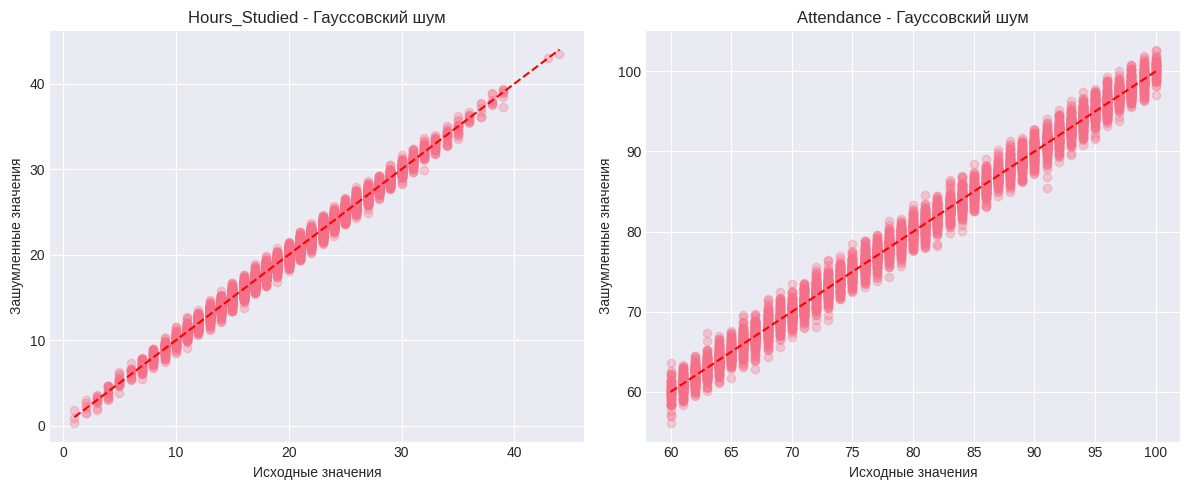

In [ ]:
# Загрузка данных
# df = pd.read_csv('StudentPerformanceFactors.csv').dropna()

# Выбираем признаки (исключая целевую переменную Exam_Score)
feature1 = 'Hours_Studied'
feature2 = 'Attendance'
target = 'Exam_Score'

print("=" * 60)
print("ДОБАВЛЕНИЕ ШУМА К ПРИЗНАКАМ")
print("=" * 60)
print()

# Функция добавления гауссовского шума
def add_gaussian_noise(data, noise_level=0.1):
    noise = np.random.normal(0, noise_level * np.std(data), len(data))
    return data + noise

# Добавляем шум
df_noisy = df.copy()
df_noisy[feature1] = add_gaussian_noise(df[feature1], noise_level=0.1)
df_noisy[feature2] = add_gaussian_noise(df[feature2], noise_level=0.1)

# Сравнение
print(f"Признак: {feature1}")
print(f"  Исходная корреляция с {target}: {df[feature1].corr(df[target]):.4f}")
print(f"  Корреляция после шума: {df_noisy[feature1].corr(df_noisy[target]):.4f}")

print(f"\nПризнак: {feature2}")
print(f"  Исходная корреляция с {target}: {df[feature2].corr(df[target]):.4f}")
print(f"  Корреляция после шума: {df_noisy[feature2].corr(df_noisy[target]):.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df[feature1], df_noisy[feature1], alpha=0.3)
axes[0].plot([df[feature1].min(), df[feature1].max()],
             [df[feature1].min(), df[feature1].max()], 'r--')
axes[0].set_xlabel('Исходные значения')
axes[0].set_ylabel('Зашумленные значения')
axes[0].set_title(f'{feature1} - Гауссовский шум')

axes[1].scatter(df[feature2], df_noisy[feature2], alpha=0.3)
axes[1].plot([df[feature2].min(), df[feature2].max()],
             [df[feature2].min(), df[feature2].max()], 'r--')
axes[1].set_xlabel('Исходные значения')
axes[1].set_ylabel('Зашумленные значения')
axes[1].set_title(f'{feature2} - Гауссовский шум')

plt.tight_layout()
plt.show()

# Сохранение
# df_noisy.to_csv('student_performance', index=False)
# print("\n✅ Зашумленный датасет сохранен в 'student_performance_noisy.csv'")
df = df_noisy

In [ ]:
# Загрузка данных
# df = pd.read_csv('StudentPerformanceFactors.csv')

print("=" * 60)
print("ПРЕОБРАЗОВАНИЕ С УДАЛЕНИЕМ СТАРЫХ КОЛОНОК")
print("=" * 60)

# Преобразование Sleep_Hours в категории
sleep_bins = [0, 5, 6, 7, 8, 9, 12]
sleep_labels = ['<5ч', '5-6ч', '6-7ч', '7-8ч', '8-9ч', '>9ч']
df['Sleep_Hours_Category'] = pd.cut(df['Sleep_Hours'], bins=sleep_bins, labels=sleep_labels)

# Преобразование Previous_Scores в категории
score_bins = [0, 60, 70, 80, 90, 100]
score_labels = ['F', 'D', 'C', 'B', 'A']
df['Previous_Scores_Category'] = pd.cut(df['Previous_Scores'], bins=score_bins, labels=score_labels)

# Удаление старых числовых колонок
df = df.drop(columns=['Sleep_Hours', 'Previous_Scores'])

# Сохранение (перезаписываем исходный файл)
df.to_csv('StudentPerformanceFactors.csv', index=False)

print(f"✅ Преобразование выполнено!")
print(f"   Добавлены колонки: 'Sleep_Hours_Category', 'Previous_Scores_Category'")
print(f"   Удалены колонки: 'Sleep_Hours', 'Previous_Scores'")
print(f"   Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
print(df[['Sleep_Hours_Category', 'Previous_Scores_Category', 'Exam_Score']].head())

ПРЕОБРАЗОВАНИЕ С УДАЛЕНИЕМ СТАРЫХ КОЛОНОК
✅ Преобразование выполнено!
   Добавлены колонки: 'Sleep_Hours_Category', 'Previous_Scores_Category'
   Удалены колонки: 'Sleep_Hours', 'Previous_Scores'
   Размер датасета: (6607, 20)

Первые 5 строк:
  Sleep_Hours_Category Previous_Scores_Category  Exam_Score
0                 6-7ч                        C          67
1                 7-8ч                        F          61
2                 6-7ч                        A          74
3                 7-8ч                        A          71
4                 5-6ч                        D          70


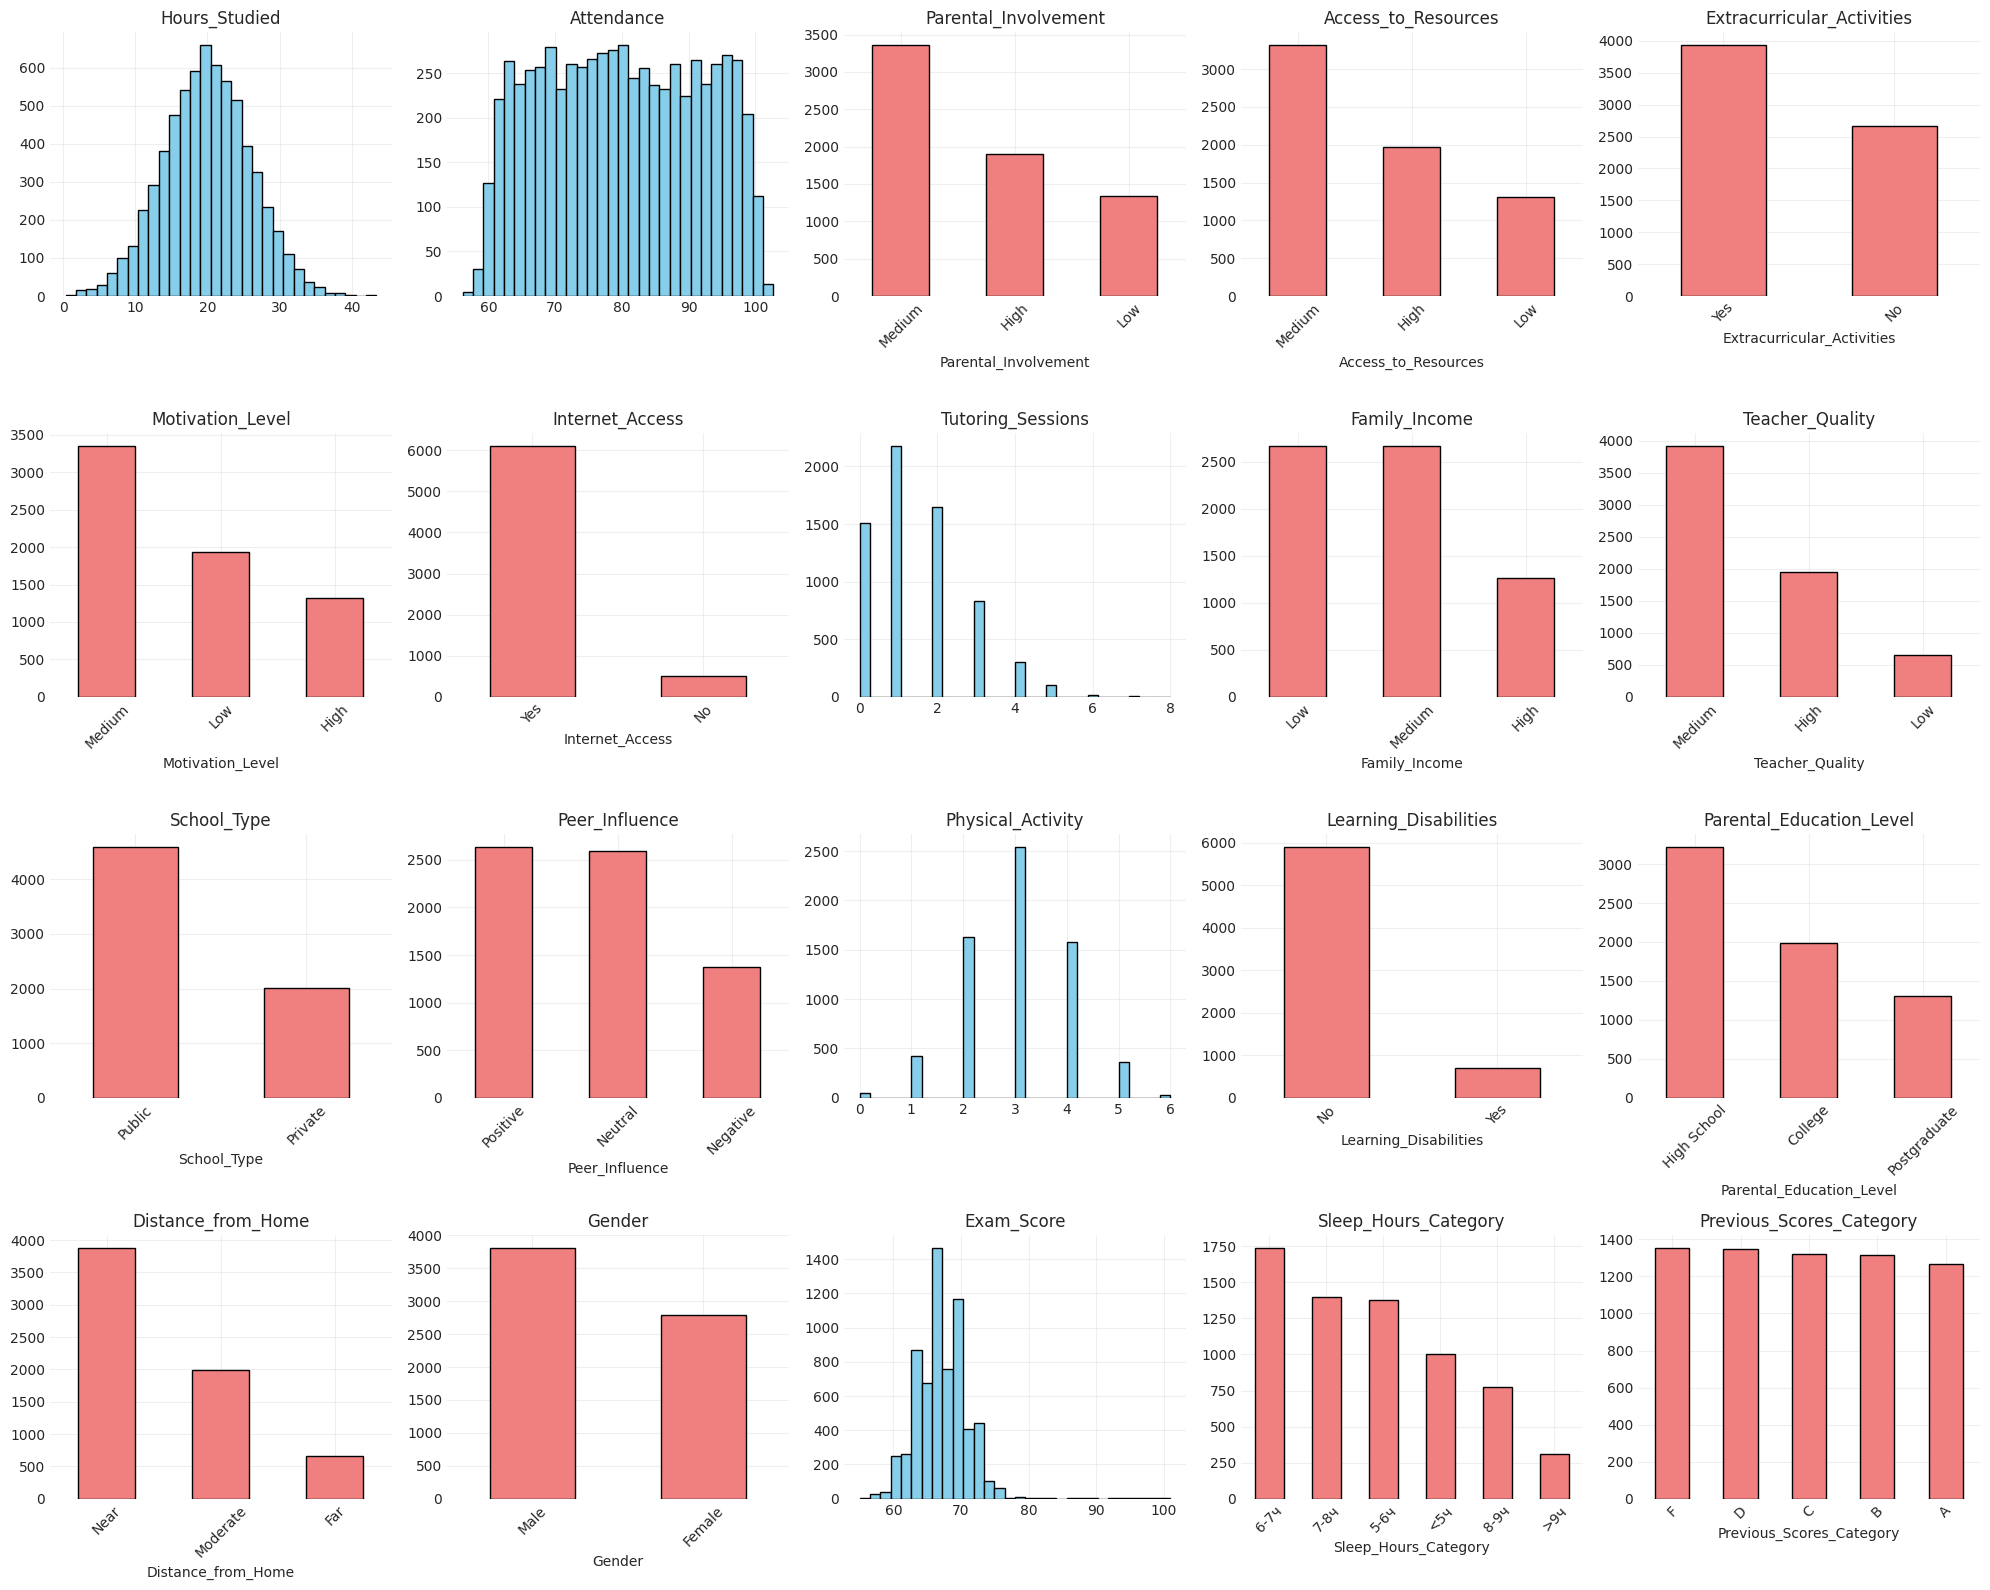

In [ ]:
# Загрузка данных
# df = pd.read_csv('StudentPerformanceFactors.csv')

# Настройка
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

# Визуализация всех признаков
for i, col in enumerate(df.columns):
    if i < len(axes):
        if df[col].dtype in ['int64', 'float64']:
            axes[i].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
            axes[i].set_title(col)
        else:
            df[col].value_counts().plot(kind='bar', ax=axes[i], color='lightcoral', edgecolor='black')
            axes[i].set_title(col)
            axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(True, alpha=0.3)

# Убираем лишние
for i in range(len(df.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Загрузка данных
# df = pd.read_csv('StudentPerformanceFactors.csv')

print("=" * 50)
print("ОБРАБОТКА ПРОПУСКОВ В ДАТАСЕТЕ")
print("=" * 50)

# Показываем пропуски до обработки
print("\nДо обработки:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

# Создаем копию
df_clean = df.copy()

# Словари для значений заполнения
categorical_fill_values = {}
numeric_fill_values = {}

# Список категориальных признаков
categorical_features = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular',
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'School_Type',
    'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level',
    'Distance_from_Home', 'Gender', 'Teacher_Quality', 'Physical_Activity'
]

# Собираем значения для заполнения категориальных признаков
for col in categorical_features:
    if col in df_clean.columns and df_clean[col].isnull().any():
        categorical_fill_values[col] = df_clean[col].mode()[0]
        print(f"  {col}: будет заполнено модой '{categorical_fill_values[col]}'")

# Список числовых признаков
numeric_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                   'Previous_Scores', 'Tutoring_Sessions', 'Exam_Score']

# Собираем значения для заполнения числовых признаков
for col in numeric_features:
    if col in df_clean.columns and df_clean[col].isnull().any():
        numeric_fill_values[col] = df_clean[col].median()
        print(f"  {col}: будет заполнено медианой {numeric_fill_values[col]}")

# Заполняем все пропуски одной операцией (самый эффективный способ)
print("\nЗаполнение пропусков...")
df_clean = df_clean.fillna(categorical_fill_values)
df_clean = df_clean.fillna(numeric_fill_values)

# Проверяем результат
print("\nПосле обработки:")
missing_after = df_clean.isnull().sum()
remaining = missing_after[missing_after > 0]

if len(remaining) == 0:
    print("Все пропуски успешно обработаны!")
else:
    print("⚠ Остались пропуски:")
    print(remaining)
    # Если остались пропуски в числовых, заполняем нулем
    for col in remaining.index:
        if col in numeric_features:
            df_clean[col] = df_clean[col].fillna(0)
            print(f"  {col}: заполнено 0")

# Сохраняем
df = df_clean
# df_clean.to_csv('student_performance_cleaned.csv', index=False)
# print("\nФайл сохранен: student_performance_cleaned.csv")

# Статистика по обработанным данным
print("\n" + "=" * 50)
print("СТАТИСТИКА ПО ОБРАБОТАННЫМ ДАННЫМ")
print("=" * 50)
print(f"Размер датасета: {df_clean.shape}")
print(f"Количество записей: {len(df_clean)}")
print(f"Количество признаков: {len(df_clean.columns)}")
print(f"Пропусков после обработки: {df_clean.isnull().sum().sum()}")

print("\nПервые 3 строки:")
print(df_clean.head(3))

ОБРАБОТКА ПРОПУСКОВ В ДАТАСЕТЕ

До обработки:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64
  Parental_Education_Level: будет заполнено модой 'High School'
  Distance_from_Home: будет заполнено модой 'Near'
  Teacher_Quality: будет заполнено модой 'Medium'

Заполнение пропусков...

После обработки:
Все пропуски успешно обработаны!

СТАТИСТИКА ПО ОБРАБОТАННЫМ ДАННЫМ
Размер датасета: (6607, 20)
Количество записей: 6607
Количество признаков: 20
Пропусков после обработки: 0

Первые 3 строки:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0      22.860769   82.967412                  Low                High   
1      19.327659   62.967507                  Low              Medium   
2      24.425030   97.463950               Medium              Medium   

  Extracurricular_Activities Motivation_Level Internet_Access  \
0                         No              Low             Yes   
1                       